In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('AB_NYC_2019.csv.xlsx')

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Rows and Columns:
(48895, 16)

Column Names:
Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

Data Types:
id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime

In [4]:
missing_values = df.isnull().sum()

print(missing_values)

id                                    0
name                                 26
host_id                               0
host_name                            22
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


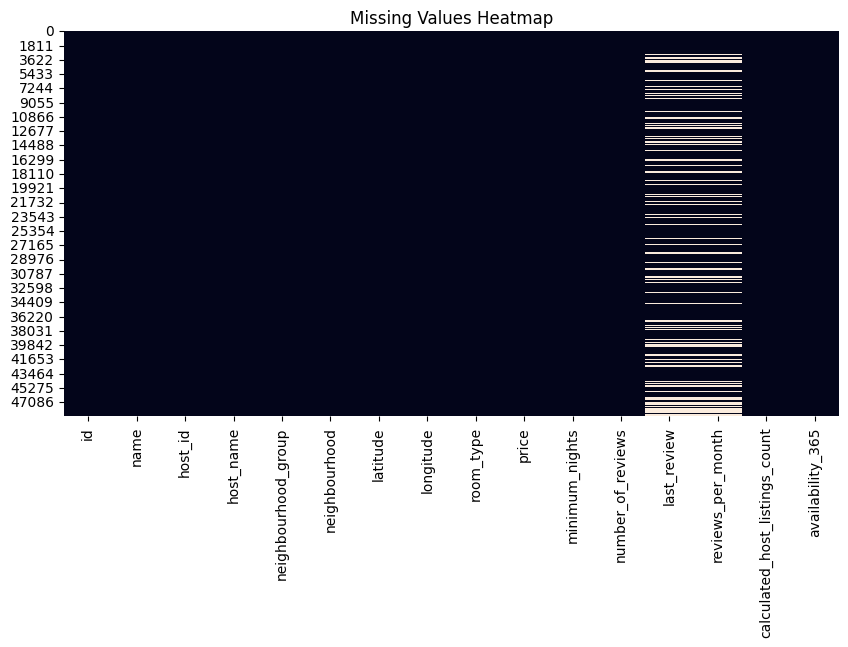

In [5]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

In [7]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(
    df['reviews_per_month'].median())
df['last_review'] = df['last_review'].fillna("Not Available")
df['name'] = df['name'].fillna("Unknown")
df['host_name'] = df['host_name'].fillna("Unknown")
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)
df.drop_duplicates(inplace=True)

Duplicate Rows: 0


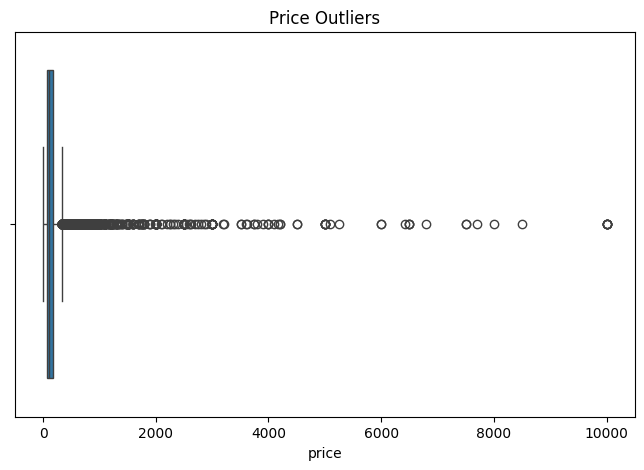

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['price'])

plt.title("Price Outliers")

plt.show()

In [10]:
Q1 = df['price'].quantile(0.25)

Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df = df[
    (df['price'] >= lower)
    &
    (df['price'] <= upper)
]

df['last_review'] = pd.to_datetime(
    df['last_review'],
    errors='coerce'
)

print(df.info())

print(df.describe())

df.to_csv(
    "cleaned_airbnb_data.csv",
    index=False
)

print("Cleaned Dataset Saved Successfully")

<class 'pandas.core.frame.DataFrame'>
Index: 45538 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              45538 non-null  int64         
 1   name                            45538 non-null  object        
 2   host_id                         45538 non-null  int64         
 3   host_name                       45538 non-null  object        
 4   neighbourhood_group             45538 non-null  object        
 5   neighbourhood                   45538 non-null  object        
 6   latitude                        45538 non-null  float64       
 7   longitude                       45538 non-null  float64       
 8   room_type                       45538 non-null  object        
 9   price                           45538 non-null  int64         
 10  minimum_nights                  45538 non-null  int64         
 11  number_